In [1]:
##############
## INITIATE ##
##############

## Imports
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Import modules
from f_dataset_wsi import WSIDatasetByInstance
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import slide_to_tiles_at_coordinates
from f_wsi_reader import read_slide
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles

#
###

In [2]:
###########################
## VISUALIZATION SCRIPT  ##
###########################

## Parameters
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0a0f8e20b1222b69416301444b117678.tiff'] # PANDA
wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/TCGA/images/svs/TCGA-EJ-5509-01A_2.svs'] # TCGA
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413)/reference/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413).png'] # SEGG

#
###

(6413, 8837)


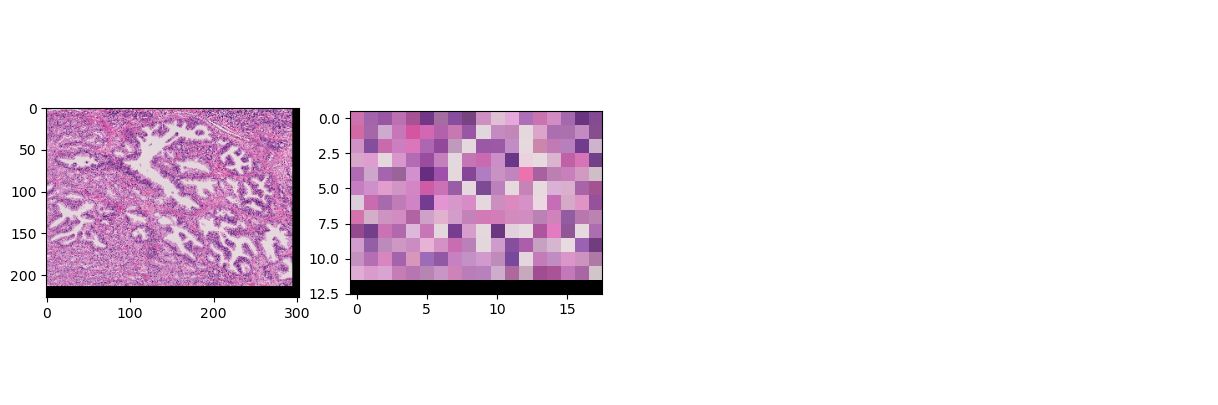

In [3]:
################## 
## GET TILE MAP ##
################## 

## Parameters
tile_size = 512

## Open slide
slide = read_slide(wsi_paths[0])
slide_size = get_dimensions(slide)
print(slide_size)

## Get tile_map
thumbnail, tile_map = get_tile_map(slide, tile_size)

## Visualise thumbnail and tile map
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
# fig.patch.set_facecolor('k')
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].axis('off')
axes[3].axis('off')
plt.show()
plt.close()

#
###

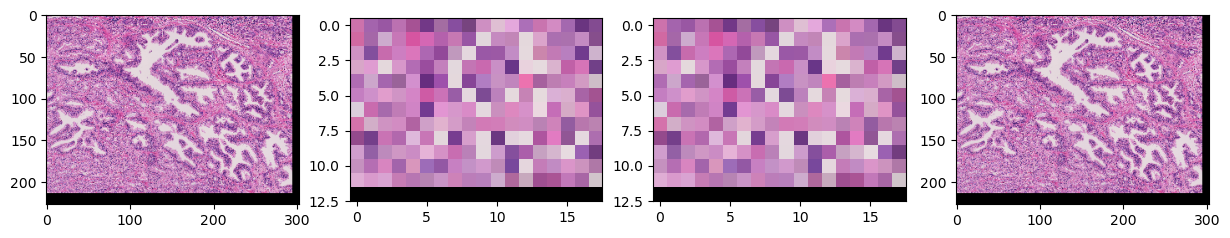

In [4]:
##########################
## SEGMENT TISSUE TILES ##
##########################

## Extract coordinates of pixels in tile_map that contain tissue
mask = apply_all_filters(tile_map)
mask = apply_all_transforms(mask)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(mask.T > 0) * tile_size).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates]

## Visualise mask
mask = mask[:,:,None]
tile_map_masked = tile_map * mask
thumbnail_masked = thumbnail * cv2.resize(mask, (thumbnail.shape[1], thumbnail.shape[0]), cv2.INTER_LINEAR)[:,:,None]
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].imshow(tile_map_masked)
axes[3].imshow(thumbnail_masked)
plt.show()
plt.close()

mask = mask[:,:,0]

#
###

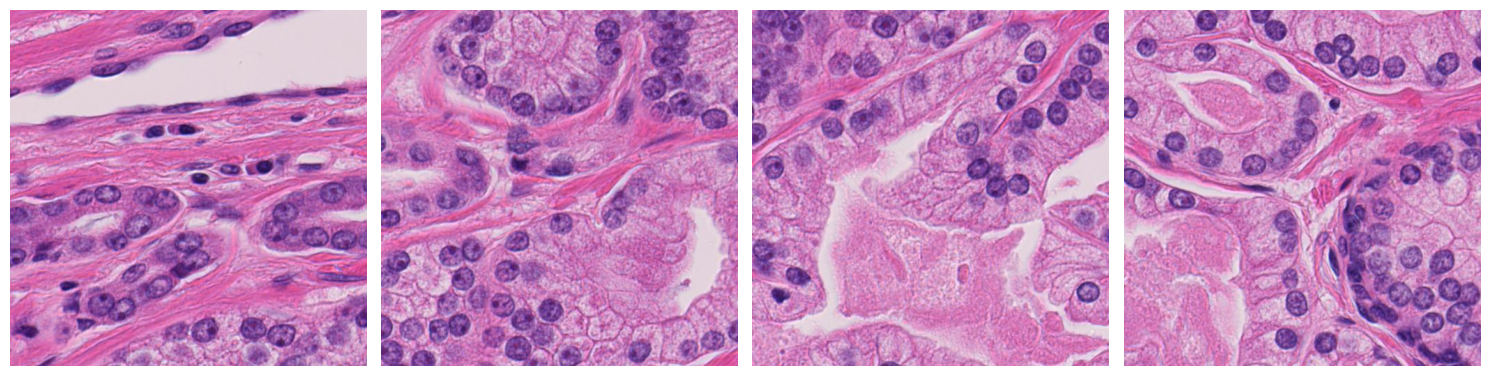

In [5]:
######################
## PATCH EXTRACTION ##
######################

## Parameters
level = 0
ds = 1
if level > 0: 
    ds = 4 * level
tile_size_ = int(tile_size/ds)

## Load patches from the dataset
patches = slide_path_to_tiles_at_coordinates(wsi_paths[0], tile_coordinates, tile_size_, level) # [dataset[i] for i in range(min(num_patches_to_display, len(dataset)))]

## Display the patches
num_patches_to_display = 4
fig, axes = plt.subplots(1, num_patches_to_display, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    if i < len(patches):
        ax.imshow(patches[i])
        ax.axis('off')
    else:
        ax.axis('off')  # Hide unused subplots if any
plt.tight_layout()
plt.show()

#
###

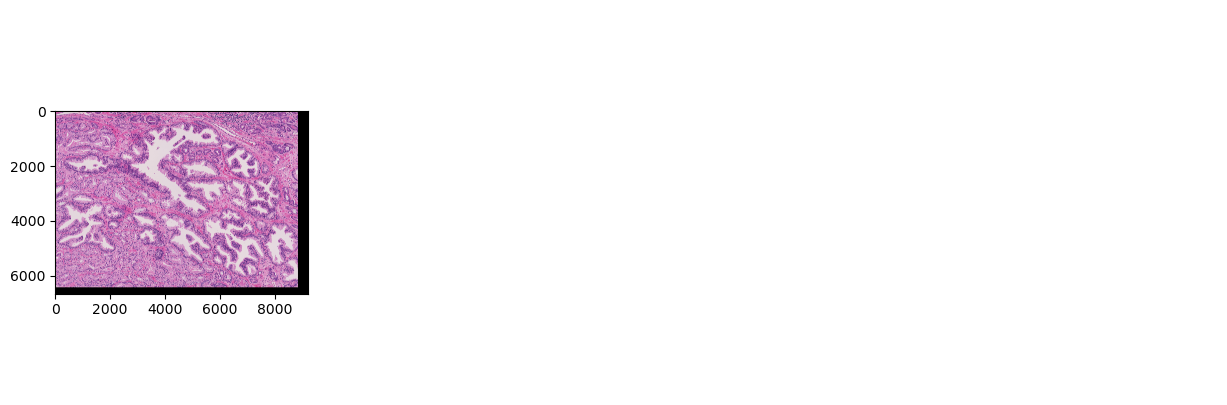

In [6]:
######################
## REASSEMBLE IMAGE ##
######################

## Convert coordinates
ds = 1
if level > 0: 
    ds = 4 * level
tile_coordinates_ds = [[int(coords_[0]/ds), int(coords_[1]/ds)] for coords_ in tile_coordinates]

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_ds)

## Visualise
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(img)
axes[1].axis('off')
axes[2].axis('off')
axes[3].axis('off')
plt.show()
plt.close()

#
###